# โครงงานการรู้จำตัวอักษรและตัวเลขภาษาไทย 72 คลาส (Thai Character Recognition)
### วิชา Deep Learning | ตามแนวทางการสอน Practical Implementation of CNNs
---
**วัตถุประสงค์ตามเกณฑ์การให้คะแนน (15%):**
1. พัฒนาแบบจำลอง CNN ร่วมกับเทคนิคการถ่ายโอนความรู้ (**Transfer Learning: 1.5%**)
2. ใช้การสังเคราะห์ข้อมูล (**Data Augmentation: 1.5%**) ที่เหมาะสมกับภาษาไทย (ไม่กลับด้านภาพ)
3. นำเสนอแนวคิดที่น่าสนใจ (**Novel / Interesting Concept: 2.0%**): การแก้ปัญหา **Class Imbalance 72 คลาส** ด้วย Class-Weighted Loss และ Cosine Annealing LR Scheduler
4. ประสิทธิภาพการทำนายภาพทดสอบ (**Test Accuracy: 5%**) และการจัดลำดับคะแนน (**Ranking: 3%**)


## 1. การเตรียมสภาพแวดล้อมและโมดูลที่จำเป็น (Environment & Imports)


In [1]:
import os
import sys
import time
import math
import random
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights, resnet50, ResNet50_Weights

# ตั้งค่า Random Seed เพื่อให้ผลลัพธ์สามารถทำซ้ำได้ (Reproducibility)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda:0


## 2. การเตรียมชุดข้อมูลและการวิเคราะห์ Class Imbalance (72 คลาส)


In [2]:
# ค้นหาและเตรียมชุดข้อมูลจากโฟลเดอร์โดยตรง (ไม่ใช้ไฟล์ CSV metadata ภายนอก)
data_dir = 'ThaiCharacter Dataset/round2' if os.path.exists('ThaiCharacter Dataset/round2') else 'ThaiCharacter Dataset'

classes = sorted(
    [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and d != '__MACOSX'],
    key=lambda x: int(x) if x.isdigit() else x
)
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for i, c in enumerate(classes)}

# ฟังก์ชันแปลงรหัส TIS-620 เป็นตัวอักษรไทย
def get_thai_char(c):
    try:
        return bytes([int(c)]).decode('tis-620')
    except Exception:
        return str(c)

# แบ่งชุดข้อมูล Train (80%) และ Val (20%) แบบ Stratified ในหน่วยความจำโดยตรง
random.seed(42)
train_records = []
val_records = []
class_sample_counts = []

for c in classes:
    c_path = os.path.join(data_dir, c)
    files = [f for f in os.listdir(c_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    class_sample_counts.append(len(files))
    shuffled = files.copy()
    random.shuffle(shuffled)
    n = len(shuffled)
    
    if n == 1:
        fp = os.path.join(c_path, shuffled[0])
        train_records.append((fp, class_to_idx[c]))
        val_records.append((fp, class_to_idx[c]))
    else:
        n_val = max(1, int(round(n * 0.2)))
        for f in shuffled[n_val:]:
            train_records.append((os.path.join(c_path, f), class_to_idx[c]))
        for f in shuffled[:n_val]:
            val_records.append((os.path.join(c_path, f), class_to_idx[c]))

print(f"Total Classes: {len(classes)} คลาส")
print(f"Training samples: {len(train_records):,} ภาพ (80%)")
print(f"Validation samples: {len(val_records):,} ภาพ (20%)")


Total Classes: 72 คลาส
Training samples: 50,162 ภาพ (80%)
Validation samples: 12,547 ภาพ (20%)


## 3. สร้าง Custom Dataset 
โครงสร้างคลาส `ThaiCharacterDataset` มี 3 เมธอดหลักคือ `__init__`, `__len__`, และ `__getitem__`


In [3]:
class ThaiCharacterDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        img_path, label = self.records[idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (64, 64), color='white')

        if self.transform:
            image = self.transform(image)

        return image, label


## 4. Data Augmentation
> ** ระวังสำคัญสำหรับตัวอักษรไทย:** **ห้ามใช้ RandomHorizontalFlip และ RandomVerticalFlip เด็ดขาด** 
> เพราะจะทำให้ความหมายของตัวอักษรเปลี่ยนไป เช่น ด กลายเป็น ค หรือ ภ กลายเป็น ถ 
> ดังนั้นเราจึงใช้ **RandomRotation (±10°)**, **RandomAffine (เลื่อน/เอียงลายมือ)** และ **ColorJitter (ความเข้มของหมึก)**


In [4]:
img_size = 64

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(degrees=(-12, 12), fill=255),
    transforms.RandomAffine(degrees=0, translate=(0.06, 0.06), scale=(0.94, 1.06), shear=(-8, 8), fill=255),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# สร้าง Dataset และ DataLoader จากข้อมูลในหน่วยความจำโดยตรง
train_dataset = ThaiCharacterDataset(train_records, transform=train_transform)
val_dataset = ThaiCharacterDataset(val_records, transform=val_transform)

batch_size = 128
num_workers = 2 if os.name != 'nt' else 0
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


Train batches: 392 | Val batches: 99


## 5. กำหนดแบบจำลอง Convolutional Neural Network (Transfer Learning)
เลือกใช้สถาปัตยกรรมหลัก **ResNet-18 (Residual Network)** สำหรับจำแนก 72 คลาส
โดยนำเอา Pretrained weights จาก ImageNet มาและปรับ Classifier Head สำหรับ 72 คลาส


In [5]:
# (1) Net: สถาปัตยกรรมแบบจำลอง ResNet-18 (Transfer Learning 72 คลาส)
def create_model(num_classes=72):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_features, num_classes)
    )
    return model

model = create_model(num_classes=len(classes))
model = model.to(device)
print(f"Model initialized: {model.__class__.__name__} for {len(classes)} classes.")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Model initialized: ResNet for 72 classes.
Total parameters: 11,213,448


## 6. กำหนด Loss Function และ Optimizer
- **Class-Weighted Cross-Entropy Loss:** คำนวณน้ำหนัก $w_c = \frac{1}{\sqrt{N_c}}$ เพื่อชดเชย Class Imbalance
- **AdamW Optimizer** ร่วมกับ **Cosine Annealing Learning Rate Scheduler**


In [6]:
# คำนวณ Class Weights แก้ปัญหา Class Imbalance (สูตร w_c = 1 / sqrt(N_c))
weights = [1.0 / math.sqrt(max(count, 1)) for count in class_sample_counts]
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
weights_tensor = weights_tensor / weights_tensor.sum() * len(classes)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
epochs = 20
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None
print("Configured Class-Weighted Cross-Entropy Loss, AdamW & Cosine Annealing Scheduler.")


Configured Class-Weighted Cross-Entropy Loss, AdamW & Cosine Annealing Scheduler.


## 7. ขั้นตอนการฝึกสอนแบบจำลอง 


In [7]:
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_top1_acc': [], 'val_top3_acc': []}

for epoch in range(1, epochs + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        
        if scaler and device.type == 'cuda':
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    scheduler.step()
    train_loss = running_loss / total
    train_acc = (correct / total) * 100.0
    
    # Validation Loop
    model.eval()
    val_loss, val_top1_correct, val_top3_correct, val_total = 0.0, 0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, top1_preds = torch.max(outputs, 1)
            val_top1_correct += (top1_preds == labels).sum().item()
            
            _, top3_preds = outputs.topk(min(3, outputs.size(1)), 1, True, True)
            val_top3_correct += top3_preds.eq(labels.view(-1, 1).expand_as(top3_preds)).sum().item()
            val_total += labels.size(0)
            
    val_loss = val_loss / val_total
    val_top1_acc = (val_top1_correct / val_total) * 100.0
    val_top3_acc = (val_top3_correct / val_total) * 100.0
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_top1_acc'].append(val_top1_acc)
    history['val_top3_acc'].append(val_top3_acc)
    
    print(f"Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Top-1: {val_top1_acc:.2f}%, Top-3: {val_top3_acc:.2f}%", end="")
    
    if val_top1_acc > best_val_acc:
        best_val_acc = val_top1_acc
        checkpoint = {
            'epoch': epoch,
            'model_name': 'resnet18',
            'model_state_dict': model.state_dict(),
            'num_classes': len(classes),
            'classes': classes,
            'val_top1_acc': val_top1_acc,
            'val_top3_acc': val_top3_acc,
            'img_size': img_size,
            'history': history
        }
        torch.save(checkpoint, 'model.pt')
        print(" -> [BEST SAVED]")
    else:
        print()


Epoch [01/20] | Train Loss: 0.4433, Acc: 91.72% | Val Loss: 0.1306, Top-1: 96.84%, Top-3: 99.74% -> [BEST SAVED]
Epoch [02/20] | Train Loss: 0.1508, Acc: 96.15% | Val Loss: 0.1473, Top-1: 96.71%, Top-3: 99.82%
Epoch [03/20] | Train Loss: 0.1206, Acc: 96.57% | Val Loss: 0.1299, Top-1: 95.37%, Top-3: 99.84%
Epoch [04/20] | Train Loss: 0.1109, Acc: 96.64% | Val Loss: 0.1086, Top-1: 96.26%, Top-3: 99.85%
Epoch [05/20] | Train Loss: 0.0957, Acc: 97.03% | Val Loss: 0.0784, Top-1: 97.57%, Top-3: 99.90% -> [BEST SAVED]
Epoch [06/20] | Train Loss: 0.0865, Acc: 97.18% | Val Loss: 0.0780, Top-1: 97.66%, Top-3: 99.90% -> [BEST SAVED]
Epoch [07/20] | Train Loss: 0.0835, Acc: 97.16% | Val Loss: 0.0814, Top-1: 97.39%, Top-3: 99.94%
Epoch [08/20] | Train Loss: 0.0774, Acc: 97.29% | Val Loss: 0.0842, Top-1: 96.98%, Top-3: 99.93%
Epoch [09/20] | Train Loss: 0.0696, Acc: 97.54% | Val Loss: 0.0851, Top-1: 96.99%, Top-3: 99.93%
Epoch [10/20] | Train Loss: 0.0665, Acc: 97.62% | Val Loss: 0.1052, Top-1: 96.3

###  Save the model that we have trained

บันทึกค่าน้ำหนัก (Model Weights) ของแบบจำลองที่ผ่านการฝึกสอนแล้วลงในไฟล์ `model.pt` และ `model.pt` เพื่อนำไปใช้งานในขั้นตอน Inference


In [ ]:
# บันทึกค่าน้ำหนักโมเดลและประวัติการฝึกสอนลงใน model.pt โดยตรง
print(f"บันทึกค่าน้ำหนักโมเดลลงใน model.pt เรียบร้อย (Best Val Accuracy: {best_val_acc:.2f}%)")

บันทึกค่าน้ำหนักโมเดลลงใน model.pt เรียบร้อย (Best Val Accuracy: 97.87%)


## 8. กราฟแสดงประสิทธิภาพแบบจำลอง 


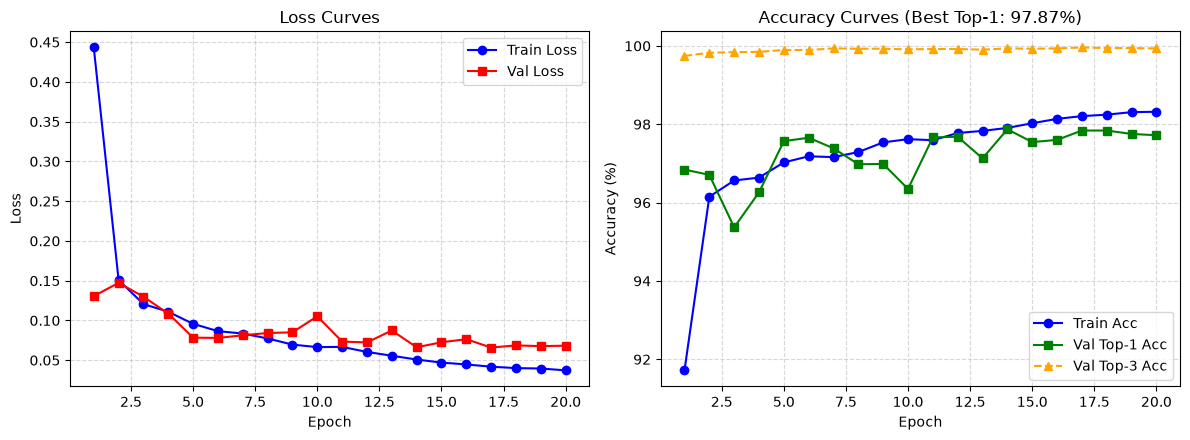

In [9]:
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(range(1, epochs + 1), history['val_loss'], label='Val Loss', color='red', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history['train_acc'], label='Train Acc', color='blue', marker='o')
plt.plot(range(1, epochs + 1), history['val_top1_acc'], label='Val Top-1 Acc', color='green', marker='s')
plt.plot(range(1, epochs + 1), history['val_top3_acc'], label='Val Top-3 Acc', color='orange', linestyle='--', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title(f'Accuracy Curves (Best Top-1: {best_val_acc:.2f}%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300)
plt.show()
